# Adaptive Multi-Stage RAG: Comparative Analysis

This notebook demonstrates the execution and evaluation of an **Adaptive Multi-Stage RAG Pipeline** compared to a baseline **Traditional RAG** pipeline. 

The evaluation measures:
1. **Retrieval Precision**: How accurately the chunks match the query context.
2. **Context Relevance**: How well the context provides information for the query.
3. **Answer Faithfulness**: Whether the LLM hallucinates or sticks to the context.
4. **Answer Relevance**: How well the final answer addresses the query.
5. **Latency**: End-to-end execution time.

*Hardware Profile Configured:* CPU Embedding + Ollama local model (`qwen2.5:1.5b`)*


In [1]:
import sys
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to front of path to avoid global library conflicts
sys.path.insert(0, 'D:/adaptive_rag_fixed')

from main import _build_or_load_index
from query_router.classifier import QueryClassifier, RetrievalConfig
from retrieval.retriever import VectorRetriever
from retrieval.reranker import CrossEncoderReranker
from retrieval.adaptive_retrieval import AdaptiveRetriever
from generation.generator import LLMGenerator
from evaluation.metrics import RAGEvaluator

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")


## 1. Document Indexing and Embedding
We will load the research paper `final_paper_after_check.pdf`, chunk it, and embed it using the CPU-based `all-MiniLM-L6-v2`.

In [2]:
# Define document and storage paths
DOC_PATH = "final_paper_after_check.pdf"
STORE_DIR = "./index_cache"
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# Build or load index
print("Loading vector index...")
store, embedder, all_chunks = _build_or_load_index(
    DOC_PATH, STORE_DIR, EMBED_MODEL, force_rebuild=False
)
print(f"Successfully loaded {len(all_chunks)} chunks.")


Loading vector index...


01:34:27  INFO      No device provided, using cpu


[Embedder] Loading: sentence-transformers/all-MiniLM-L6-v2


01:34:28  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
01:34:28  WARNING   Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
01:34:28  INFO      HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
01:34:28  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
01:34:28  INFO      HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
01:34:28  INFO      Loading SentenceTransformer model from sentence-transformers/a

[Store] Saved 24 vectors to './index_cache\\index_b0a1a43b'
Successfully loaded 24 chunks.


## 2. Pipeline Initialization
We define the shared components. The LLM Generator uses `ollama` with the `qwen2.5:1.5b` model to ensure strict memory constraints are met.


In [3]:
# Initialize core pipeline components
clf = QueryClassifier()
retriever = VectorRetriever(store, embedder, default_top_k=3)
reranker = CrossEncoderReranker()
adaptive_retriever = AdaptiveRetriever(retriever, reranker, clf)
evaluator = RAGEvaluator()

# Initialize LLM backend
backend_type = "ollama"
llm_model = "qwen2.5:1.5b"
generator = LLMGenerator(backend=backend_type, model_name=llm_model)

print(f"Initialized LLM Generator with {backend_type} / {llm_model}")


Initialized LLM Generator with ollama / qwen2.5:1.5b


## 3. Define Test Queries
We evaluate the pipeline on three distinct query types to test reasoning, summarization, and direct factual extraction.

In [4]:
test_queries = [
    "What is the main contribution of this paper regarding air quality prediction?", # Summarization
    "How does the GA-Opt RF model compare against the SVR model in terms of RMSE?", # Reasoning / Multi-hop
    "What dataset was used for evaluating the synthetic results?" # Factual
]


## 4. Execution & Comparative Analysis
We run each query twice:
1. **Baseline**: Static Top-K=3, no reranking.
2. **Adaptive**: Uses query routing, dynamic K allocation, and cross-encoder reranking.


In [5]:
results_data = []

print("Running comparative analysis (this may take a few minutes)...\n")

for i, query in enumerate(test_queries):
    print(f"--- Query {i+1}: {query} ---")
    
    # ---------------------------------------------------------
    # Configuration 1: BASELINE RAG
    # ---------------------------------------------------------
    t0 = time.perf_counter()
    # Force baseline config: fixed k=3, no reranking
    baseline_config = RetrievalConfig(query_type="factual", top_k=3, rerank=False, iterative=False, context_budget=512, confidence_threshold=0.5)
    
    ctx_baseline = adaptive_retriever.retrieve(query, config=baseline_config)
    res_baseline = generator.generate(ctx_baseline)
    lat_baseline = time.perf_counter() - t0
    
    eval_baseline = evaluator.evaluate(res_baseline, ctx_baseline, lat_baseline)
    
    results_data.append({
        "Query": f"Q{i+1}",
        "Method": "Baseline RAG",
        "Retrieval Precision": eval_baseline.retrieval_precision,
        "Context Relevance": eval_baseline.context_relevance,
        "Answer Faithfulness": eval_baseline.answer_faithfulness,
        "Answer Relevance": eval_baseline.answer_relevance,
        "Latency (s)": eval_baseline.latency_seconds
    })
    
    # ---------------------------------------------------------
    # Configuration 2: ADAPTIVE RAG
    # ---------------------------------------------------------
    t0 = time.perf_counter()
    # Let the classifier decide the optimal config
    adaptive_config = clf.classify(query)
    
    ctx_adaptive = adaptive_retriever.retrieve(query, config=adaptive_config)
    res_adaptive = generator.generate(ctx_adaptive)
    lat_adaptive = time.perf_counter() - t0
    
    eval_adaptive = evaluator.evaluate(res_adaptive, ctx_adaptive, lat_adaptive)
    
    results_data.append({
        "Query": f"Q{i+1}",
        "Method": "Adaptive RAG",
        "Retrieval Precision": eval_adaptive.retrieval_precision,
        "Context Relevance": eval_adaptive.context_relevance,
        "Answer Faithfulness": eval_adaptive.answer_faithfulness,
        "Answer Relevance": eval_adaptive.answer_relevance,
        "Latency (s)": eval_adaptive.latency_seconds
    })
    print(f"✅ Q{i+1} Processed.\n")

df_results = pd.DataFrame(results_data)
display(df_results)


Running comparative analysis (this may take a few minutes)...

--- Query 1: What is the main contribution of this paper regarding air quality prediction? ---


[Router] 'What is the main contribution of this paper regard' -> reasoning (k=7)


01:35:00  INFO      HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
01:35:01  INFO      HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 404 Not Found"
01:35:01  INFO      No modules.json found for cross-encoder/ms-marco-MiniLM-L-6-v2, initializing a new CrossEncoder model.
01:35:01  INFO      HTTP Request: GET https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L-6-v2 "HTTP/1.1 307 Temporary Redirect"
01:35:01  INFO      HTTP Request: GET https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L6-v2 "HTTP/1.1 200 OK"
01:35:01  INFO      HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
01:35:02  INFO      HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Tempo

✅ Q1 Processed.

--- Query 2: How does the GA-Opt RF model compare against the SVR model in terms of RMSE? ---
[Router] 'How does the GA-Opt RF model compare against the S' -> reasoning (k=7)
✅ Q2 Processed.

--- Query 3: What dataset was used for evaluating the synthetic results? ---
[Router] 'What dataset was used for evaluating the synthetic' -> reasoning (k=7)
✅ Q3 Processed.



,Query,Method,Retrieval Precision,Context Relevance,Answer Faithfulness,Answer Relevance,Latency (s)
0,Q1,Baseline RAG,1.000000,0.571429,0.000000,0.0,21.752323
1,Q1,Adaptive RAG,1.000000,0.714286,0.142857,0.0,16.076464
2,Q2,Baseline RAG,1.000000,0.285714,0.000000,0.0,2.082453
3,Q2,Adaptive RAG,0.600000,0.571429,0.142857,0.0,9.189764
4,Q3,Baseline RAG,1.000000,0.800000,0.142857,0.0,7.042516
5,Q3,Adaptive RAG,0.666667,1.000000,0.142857,0.0,15.655052


## 5. Visualizing the Results
We plot the performance metrics across all test queries to visualize the impact of the Adaptive routing and reranking.

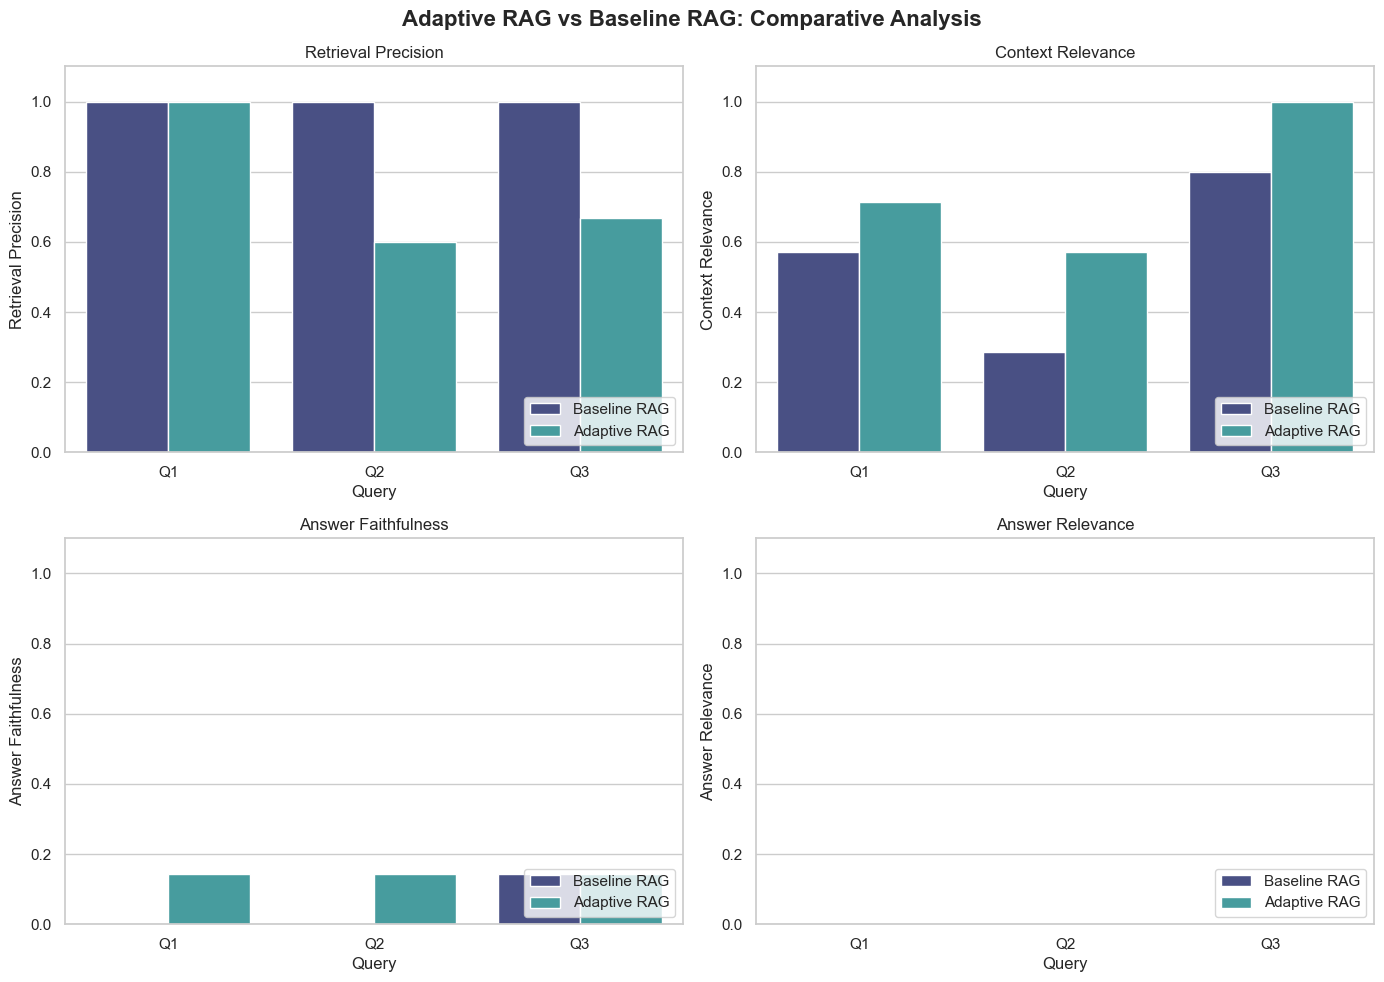

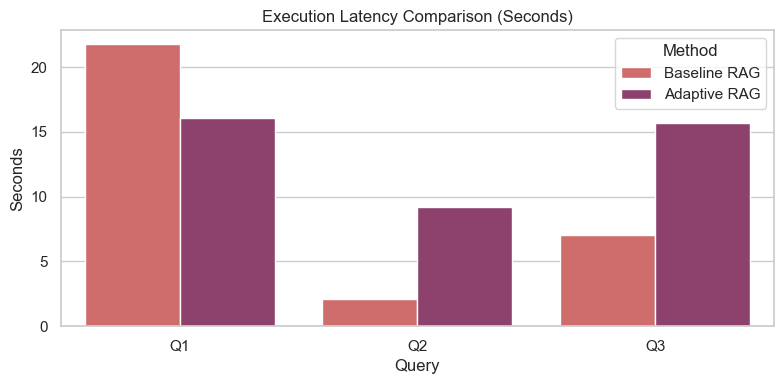

In [6]:
# Set up the matplotlib figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Adaptive RAG vs Baseline RAG: Comparative Analysis', fontsize=16, fontweight='bold')

metrics_to_plot = [
    ("Retrieval Precision", axes[0, 0]),
    ("Context Relevance", axes[0, 1]),
    ("Answer Faithfulness", axes[1, 0]),
    ("Answer Relevance", axes[1, 1])
]

for metric, ax in metrics_to_plot:
    sns.barplot(data=df_results, x="Query", y=metric, hue="Method", ax=ax, palette="mako")
    ax.set_title(metric)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Separate plot for Latency
plt.figure(figsize=(8, 4))
sns.barplot(data=df_results, x="Query", y="Latency (s)", hue="Method", palette="flare")
plt.title("Execution Latency Comparison (Seconds)")
plt.ylabel("Seconds")
plt.tight_layout()
plt.show()
